# 1. Преобразование датасета
В датасет из предыдущей работы у каждого прослушивания добавим сгенерируемую дату, когда прослушали трек. Все сделаные даты буду равномерно распределены на промежутке 1 сентября 2024 и 30 ноября 2024.  

In [3]:
import pandas as pd

df = pd.read_csv('dataset.csv')

In [5]:
import numpy as np
start_date = pd.Timestamp('2024-09-01')
end_date = pd.Timestamp('2024-11-30')
df['listening_time'] = pd.to_datetime(
    np.random.uniform(start_date.value, end_date.value, size=len(df)),
    unit='ns'
)

df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,user_id,track_id,tags,year,duration_ms,listening_time
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRTUCUY128F92E1D24,"rock, alternative, alternative_rock, hard_rock...",1999,256440,2024-11-26 07:09:47.073618944
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRRYCBO128F932A2C7,"rock, alternative, pop, dance, 80s, new_wave",2010,323586,2024-11-19 18:56:15.273431040
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRUTULC128F4293712,"rock, alternative_rock, hard_rock, grunge",1999,222200,2024-10-10 15:41:20.636222464
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRAAHSY128F147BB5C,"rock, alternative, indie, pop, alternative_roc...",2008,287906,2024-10-10 07:21:19.323008000
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,TRDLMWP128F426BF6C,"rock, alternative, indie, folk, indie_rock, 00...",2008,305320,2024-10-15 07:29:34.560578304


In [6]:
# 1. Суммарное время прослушивания за каждую неделю
# Добавляем колонку с неделей года
df['week'] = df['listening_time'].dt.isocalendar().week

# Группируем по user_id и неделям, суммируем время (в секундах)
weekly_summary = df.groupby(['user_id', 'week'], as_index=False)['duration_ms'].sum()
weekly_summary['duration_seconds'] = weekly_summary['duration_ms'] / 1000
weekly_summary.drop('duration_ms', axis=1, inplace=True)

# 2. Флаг прослушивания хотя бы одной песни из 2008 года
df['is_2008'] = df['year'] == 2008
user_flag_2008 = df.groupby(['user_id', 'week'], as_index=False)['is_2008'].any()
user_flag_2008.rename(columns={'is_2008': 'listened_2008_flag'}, inplace=True)

# Итоговый результат: объединяем таблицы
final_result = pd.merge(weekly_summary, user_flag_2008, on=['user_id', 'week'])

In [35]:
all_users = df['user_id'].unique()
all_weeks = range(df['week'].min(), df['week'].max() + 1)
all_combinations = pd.MultiIndex.from_product([all_users, all_weeks], names=['user_id', 'week']).to_frame(index=False)

final_summary = pd.merge(all_combinations, final_result, on=['user_id', 'week'], how='left')
final_summary['duration_seconds'] = final_summary['duration_seconds'].fillna(0)
final_summary['listened_2008_flag'] = final_summary['listened_2008_flag'].fillna(False)

C:\Users\krasn\AppData\Local\Temp\ipykernel_33216\3274375551.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_summary['listened_2008_flag'] = final_summary['listened_2008_flag'].fillna(False)


**Итоговый датафрейм для одного пользователя**

In [36]:
final_summary['listened_2008_flag'] = final_summary['listened_2008_flag'].fillna(False)
final_summary[final_summary['user_id']=='b80344d063b5ccb3212f76538f3d9e43d87dca9e'].head(15)

,user_id,week,duration_seconds,listened_2008_flag
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,35,0.000,False
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,36,201.560,False
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,37,0.000,False
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,38,240.200,False
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,39,0.000,False
5,b80344d063b5ccb3212f76538f3d9e43d87dca9e,40,0.000,False
6,b80344d063b5ccb3212f76538f3d9e43d87dca9e,41,510.106,True
7,b80344d063b5ccb3212f76538f3d9e43d87dca9e,42,305.320,True
8,b80344d063b5ccb3212f76538f3d9e43d87dca9e,43,500.133,False
9,b80344d063b5ccb3212f76538f3d9e43d87dca9e,44,0.000,False


In [10]:
final_summary.to_csv('week_dataset.csv', index=False)

# 2. Графический способ
Для начала посмотрим графике, как средние изменяются по неделям. 

In [37]:
import matplotlib.pyplot as plt
valid_weeks = final_summary['week'].unique()
# Исключение первой и последней недели, т.к. они неполные
df_without_extreme_weeks = final_summary[final_summary['week'].between(valid_weeks.min() + 1, valid_weeks.max() - 1)]

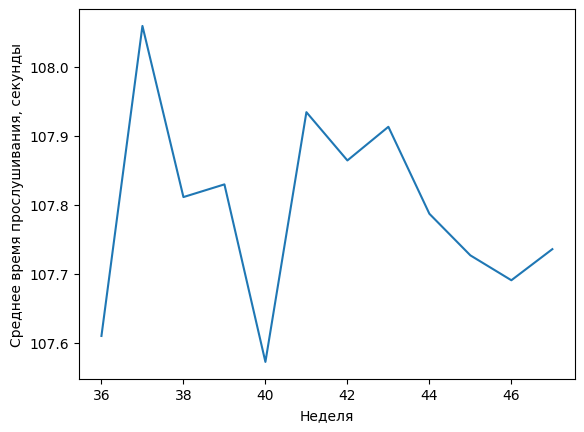

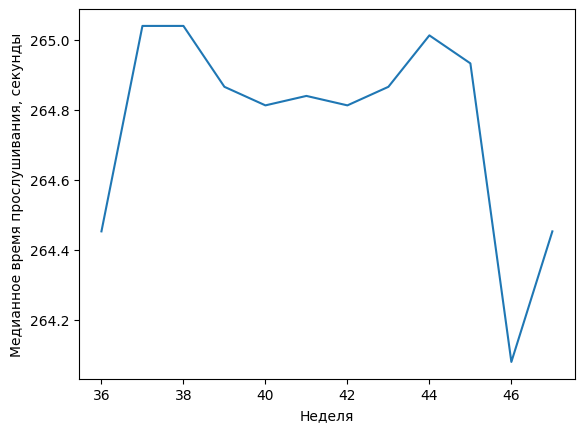

In [38]:
df_without_extreme_weeks.groupby('week')['duration_seconds'].mean().plot()
plt.ylabel('Среднее время прослушивания, секунды')
plt.xlabel('Неделя')
plt.show()

# Медианное время прослушивания за неделю
df_without_extreme_weeks.where(df_without_extreme_weeks['duration_seconds']>0).groupby('week')['duration_seconds'].median().plot()
plt.ylabel('Медианное время прослушивания, секунды')
plt.xlabel('Неделя')
plt.show()

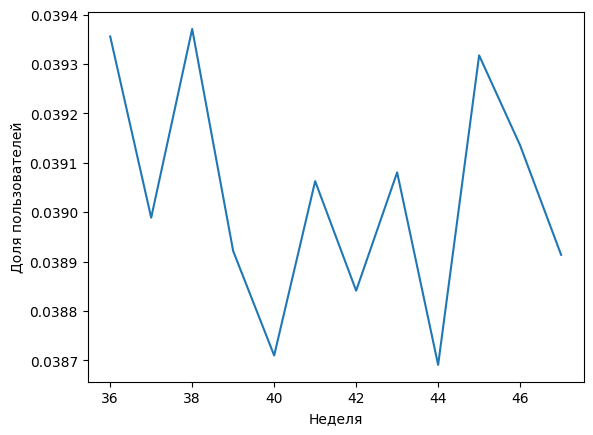

In [34]:
# Построить график доли пользователей, прослушавших хотя бы одну песню из 2008 года
df_without_extreme_weeks.groupby('week')['listened_2008_flag'].mean().plot()
plt.ylabel('Доля пользователей')
plt.xlabel('Неделя')
plt.show()

**Вывод:** Сложно определить, скачки, если есть, то они маленькие(Доли изменяются на 0.0001, среднее меньше чем на секунду). 

# 3. Тесты об одинаковасти распределений

Для непрерывного распределения будет использовать тест Манна-Уитни-Уилкесона, а для дискретного хи-квадрат.

In [39]:
from scipy.stats import mannwhitneyu, chi2_contingency
# 1. Тест Манна-Уитни для продолжительности

for week in range(valid_weeks.min(), valid_weeks.max()):
    group_1 = final_summary[final_summary['week'] == week]['duration_seconds']
    group_2 = final_summary[final_summary['week'] == week + 1]['duration_seconds']

    u_stat, p_value = mannwhitneyu(group_1, group_2, alternative='two-sided')
    print(f"Недели {week} и {week + 1}: p-значение = {p_value}")

Недели 35 и 36: p-значение = 0.0
Недели 36 и 37: p-значение = 0.696755227342395
Недели 37 и 38: p-значение = 0.6960276519406394
Недели 38 и 39: p-значение = 0.5535577913757376
Недели 39 и 40: p-значение = 0.9462310507931322
Недели 40 и 41: p-значение = 0.2903981162271103
Недели 41 и 42: p-значение = 0.9509560118829501
Недели 42 и 43: p-значение = 0.5806836102934647
Недели 43 и 44: p-значение = 0.49482524311100184
Недели 44 и 45: p-значение = 0.21386807587869183
Недели 45 и 46: p-значение = 0.43664290274073203
Недели 46 и 47: p-значение = 0.8145248597686869
Недели 47 и 48: p-значение = 0.0


In [43]:
# 2. Хи-квадрат тест для флага прослушивания песен из 2008 года
# Создаём таблицу сопряжённости
contingency_table = pd.crosstab(df_without_extreme_weeks['week'], df_without_extreme_weeks['listened_2008_flag'])
print(contingency_table)

listened_2008_flag   False  True 
week                             
36                  753557  30872
37                  753845  30584
38                  753545  30884
39                  753898  30531
40                  754064  30365
41                  753787  30642
42                  753961  30468
43                  753773  30656
44                  754079  30350
45                  753587  30842
46                  753730  30699
47                  753904  30525


In [45]:
# Хи-квадрат тест для всех недель одновременно кроме первой и последней
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Хи-квадрат тест: p-значение = {p_value_chi2}")

Хи-квадрат тест: p-значение = 0.32262169424342096


In [46]:
for week in range(valid_weeks.min(), valid_weeks.max()):

    # Таблица сопряжённости для текущей и следующей недели
    subset = final_summary[final_summary['week'].isin([week, week+1])]
    contingency_table = pd.crosstab(subset['week'], subset['listened_2008_flag'])

    # Проверка хи-квадрат тестом
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"Недели {week} и {week + 1}: p-значение = {p_value}")


Недели 35 и 36: p-значение = 0.0
Недели 36 и 37: p-значение = 0.23757341674711524
Недели 37 и 38: p-значение = 0.21856927408648097
Недели 38 и 39: p-значение = 0.14732973866222057
Недели 39 и 40: p-значение = 0.4952371577860105
Недели 40 и 41: p-значение = 0.2543661352018035
Недели 41 и 42: p-значение = 0.4753093304971939
Недели 42 и 43: p-значение = 0.44037983835359185
Недели 43 и 44: p-значение = 0.2078206334426013
Недели 44 и 45: p-значение = 0.04289207967006487
Недели 45 и 46: p-значение = 0.5592359248944211
Недели 46 и 47: p-значение = 0.4757039455981623
Недели 47 и 48: p-значение = 5.570661515806294e-303


**Вывод:** Что 35(Первая) неделя и 48(Последняя) не похожи на другие - это было понятно, так как они не полные. А так тесты не опревергают, что распределения каждых недель одинаковы, только есть спорный момент между 44 и 45 неделями в дискретном распределении, который нужно будет дальше проанализировать.  

# 4. PSI - тест
Теперь проверим с помощью PSI - теста непрерывное распределение. И посмотрим как он сочитается с тестом Манна-Уитни.

In [47]:
import pandas as pd
import numpy as np

def calculate_psi(expected, actual, bins=10):
    bin_edges = np.linspace(min(expected.min(), actual.min()), max(expected.max(), actual.max()), bins + 1)
    
    expected_dist, _ = np.histogram(expected, bins=bin_edges)
    actual_dist, _ = np.histogram(actual, bins=bin_edges)
    
    # Нормализуем распределения
    expected_dist = expected_dist / len(expected)
    actual_dist = actual_dist / len(actual)
    
    # Заменяем нули в распределении, чтобы избежать деления на 0
    expected_dist = np.where(expected_dist == 0, 0.0001, expected_dist)
    actual_dist = np.where(actual_dist == 0, 0.0001, actual_dist)
    
    # Рассчитываем PSI
    psi_values = (expected_dist - actual_dist) * np.log(expected_dist / actual_dist)
    psi_value = np.sum(psi_values)
    
    return psi_value

In [48]:
for week in range(valid_weeks.min(), valid_weeks.max()):
    expected_week = final_summary[final_summary['week'] == week]['duration_seconds']
    actual_week = final_summary[final_summary['week'] == week + 1]['duration_seconds']

    psi_result = calculate_psi(expected_week, actual_week, bins=20)
    print(f"PSI между неделями {week} и {week + 1}: {psi_result}")

PSI между неделями 35 и 36: 0.2498518784330803
PSI между неделями 36 и 37: 0.0013214974846209985
PSI между неделями 37 и 38: 0.00046596843648390656
PSI между неделями 38 и 39: 0.0012124169206604246
PSI между неделями 39 и 40: 0.0013200924271578433
PSI между неделями 40 и 41: 0.0009169224762029794
PSI между неделями 41 и 42: 0.0003586152146046768
PSI между неделями 42 и 43: 0.00165628189568742
PSI между неделями 43 и 44: 0.002114759595502881
PSI между неделями 44 и 45: 0.0011176037232914278
PSI между неделями 45 и 46: 0.0004484901221138948
PSI между неделями 46 и 47: 0.0007350532322006269
PSI между неделями 47 и 48: 0.016838611232830238


**Выводы:** PSI-тест подтвердил результаты теста Манна-Уитни, что значимых изменений данных между неделями нет, кроме как у первой и последней неделе. 